# Stage 2: Returns and Risk

This notebook transforms Stage 1 price data into portfolio-ready return and volatility outputs. It keeps the runtime Yahoo Finance access pattern unchanged and performs all analytics in memory.

## Why Returns and Volatility Matter

- Portfolio optimization does not use raw prices directly because assets trade at different absolute price levels.
- Returns convert price changes into a comparable scale across assets.
- Simple returns are intuitive percentage changes.
- Log returns are additive through time and are the default Stage 2 output for downstream risk analysis.
- Volatility measures how much returns vary over time and serves as a first-pass risk proxy before covariance and correlation are studied in later stages.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_pipeline import SAMPLE_UNIVERSE, DataPreprocessor, YahooFinanceProvider

In [18]:
symbols = list(SAMPLE_UNIVERSE)
start_date = "2020-01-01"
end_date = "2024-12-31"

provider = YahooFinanceProvider()
market_data = provider.get_market_data(symbols, start_date, end_date)

prices_df = DataPreprocessor.handle_missing_values(market_data.prices_df)
volume_df = market_data.volume_df.copy()

stage_2_outputs = DataPreprocessor.build_returns_risk_outputs(prices_df)

simple_returns_df = stage_2_outputs.simple_returns_df
returns_df = stage_2_outputs.returns_df
log_returns_df = stage_2_outputs.log_returns_df
volatility_summary_df = stage_2_outputs.volatility_summary_df
rolling_volatility_df = stage_2_outputs.rolling_volatility_df
return_comparison_df = stage_2_outputs.return_comparison_df

print(f"prices_df shape: {prices_df.shape}")
print(f"volume_df shape: {volume_df.shape}")
print(f"simple_returns_df shape: {simple_returns_df.shape}")
print(f"log_returns_df shape: {log_returns_df.shape}")
print(f"rolling_volatility_df shape: {rolling_volatility_df.shape}")

prices_df shape: (1237, 3)
volume_df shape: (1237, 3)
simple_returns_df shape: (1236, 3)
log_returns_df shape: (1236, 3)
rolling_volatility_df shape: (1236, 6)


In [19]:
prices_df.head()

Ticker,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
Date,,,
2020-01-01,34.349998,605.529358,1841.149658
2020-01-02,34.349998,609.389160,1832.698364
2020-01-03,35.400002,600.698853,1869.221924
2020-01-06,36.150002,587.698853,1869.052124
2020-01-07,35.500000,597.004883,1873.639282


In [20]:
display(simple_returns_df.head())
display(log_returns_df.head())
display(return_comparison_df)
display(volatility_summary_df)

Ticker,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
Date,,,
2020-01-02,0.000000,0.006374,-0.004590
2020-01-03,0.030568,-0.014261,0.019929
2020-01-06,0.021186,-0.021641,-0.000091
2020-01-07,-0.017981,0.015835,0.002454
2020-01-08,0.016901,-0.002618,0.022395


asset,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
Date,,,
2020-01-02,0.000000,0.006354,-0.004601
2020-01-03,0.030110,-0.014363,0.019733
2020-01-06,0.020965,-0.021879,-0.000091
2020-01-07,-0.018144,0.015711,0.002451
2020-01-08,0.016760,-0.002621,0.022148


,mean_simple_return,mean_log_return,mean_abs_difference,max_abs_difference,return_correlation
asset,,,,,
GOLDBEES.NS,0.000542,0.000503,0.000039,0.001107,0.999944
HDFCBANK.NS,0.000448,0.000300,0.000148,0.008685,0.999609
TCS.NS,0.000725,0.000606,0.000119,0.004727,0.999786


,daily_volatility,annualized_volatility,annualization_factor
asset,,,
GOLDBEES.NS,0.008813,0.139903,252
HDFCBANK.NS,0.017232,0.273544,252
TCS.NS,0.015412,0.244657,252


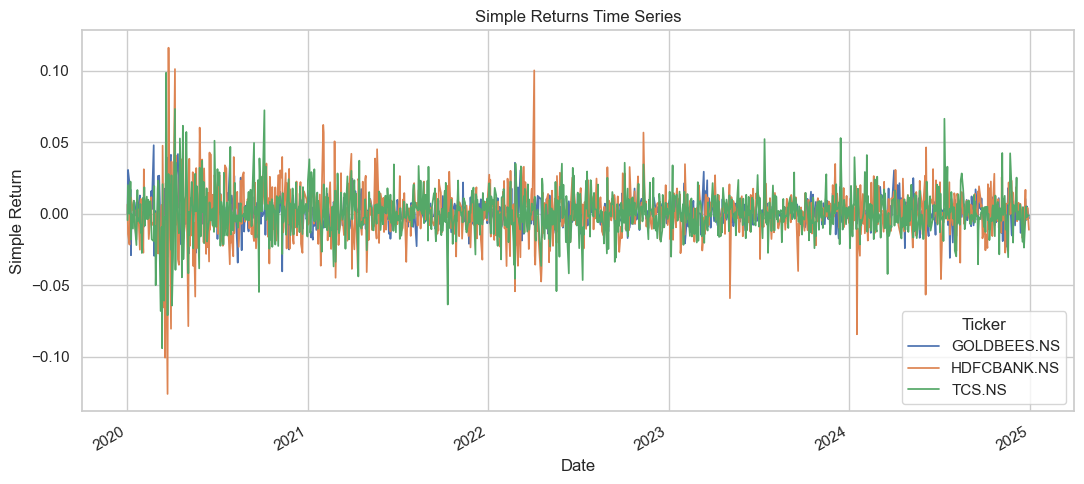

In [21]:
sns.set_theme(style="whitegrid")
ax = simple_returns_df.plot(figsize=(11, 5), linewidth=1.25)
ax.set_title("Simple Returns Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Simple Return")
plt.tight_layout()

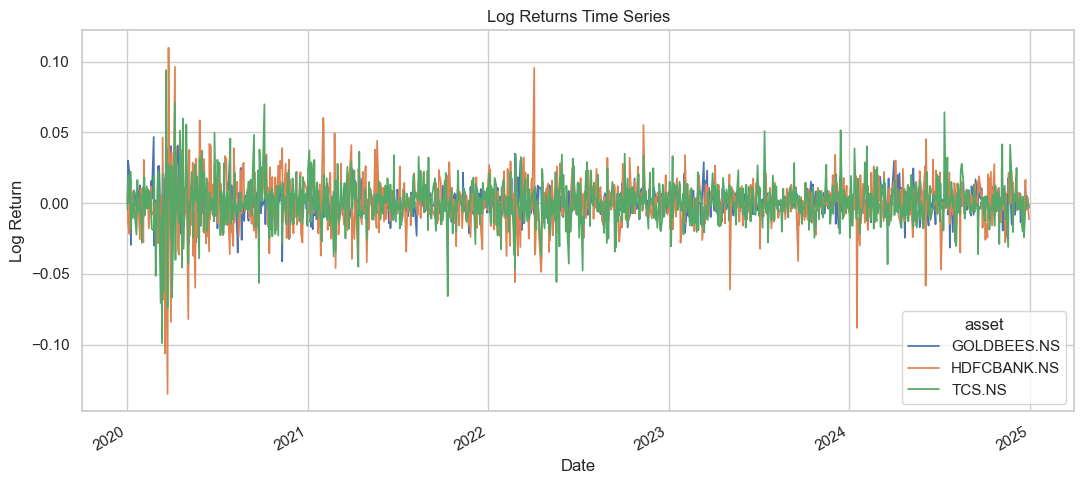

In [22]:
ax = log_returns_df.plot(figsize=(11, 5), linewidth=1.25)
ax.set_title("Log Returns Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
plt.tight_layout()

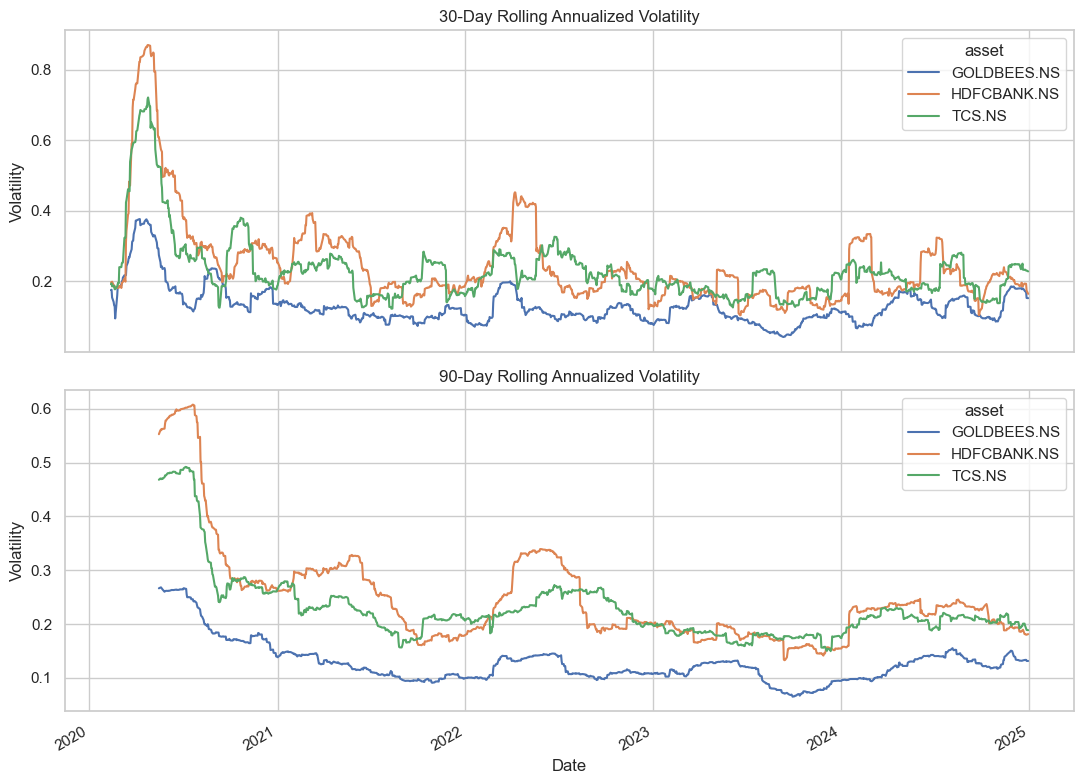

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
rolling_volatility_df.xs("30d", axis=1, level="window").plot(ax=axes[0], linewidth=1.5)
axes[0].set_title("30-Day Rolling Annualized Volatility")
axes[0].set_ylabel("Volatility")

rolling_volatility_df.xs("90d", axis=1, level="window").plot(ax=axes[1], linewidth=1.5)
axes[1].set_title("90-Day Rolling Annualized Volatility")
axes[1].set_ylabel("Volatility")
axes[1].set_xlabel("Date")
plt.tight_layout()

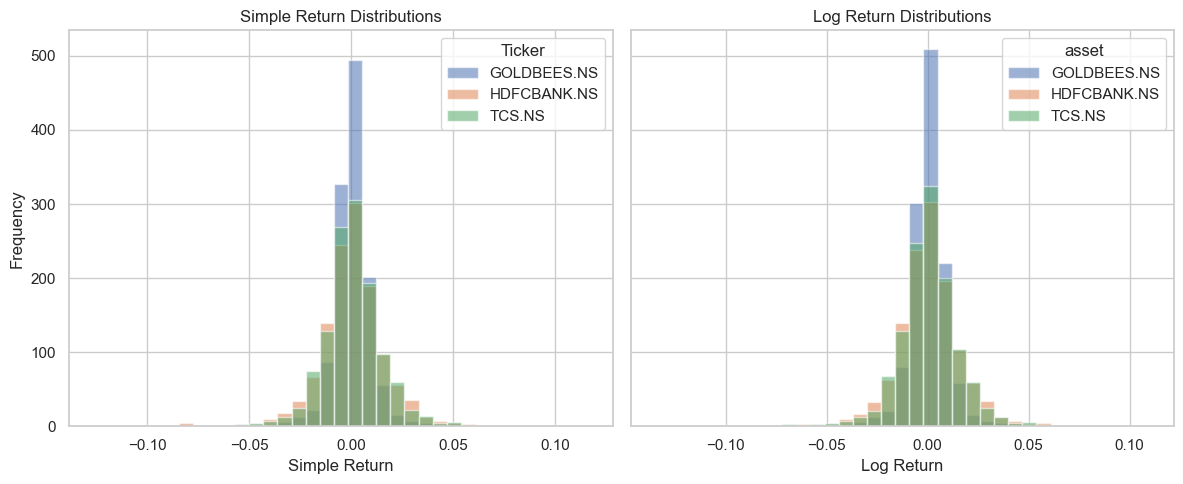

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
simple_returns_df.plot(kind="hist", bins=35, alpha=0.55, ax=axes[0])
axes[0].set_title("Simple Return Distributions")
axes[0].set_xlabel("Simple Return")

log_returns_df.plot(kind="hist", bins=35, alpha=0.55, ax=axes[1])
axes[1].set_title("Log Return Distributions")
axes[1].set_xlabel("Log Return")
plt.tight_layout()

## Interpretation

- `returns_df` is intentionally set equal to `log_returns_df` so downstream stages default to log returns.
- The difference between simple and log returns is small for daily data, but log returns compose more cleanly across time.
- Annualized volatility scales daily dispersion by the square root of trading days and gives a comparable risk summary across assets.
- Rolling volatility reveals how risk changes over time, which is essential before building covariance and correlation matrices in the next approved stage.

In [25]:
volatility_summary_df

,daily_volatility,annualized_volatility,annualization_factor
asset,,,
GOLDBEES.NS,0.008813,0.139903,252
HDFCBANK.NS,0.017232,0.273544,252
TCS.NS,0.015412,0.244657,252


In [26]:
return_comparison_df


,mean_simple_return,mean_log_return,mean_abs_difference,max_abs_difference,return_correlation
asset,,,,,
GOLDBEES.NS,0.000542,0.000503,0.000039,0.001107,0.999944
HDFCBANK.NS,0.000448,0.000300,0.000148,0.008685,0.999609
TCS.NS,0.000725,0.000606,0.000119,0.004727,0.999786


In [27]:
return_summary_df = pd.DataFrame({
    "Mean Return": simple_returns_df.mean(),
    "Median Return": simple_returns_df.median(),
    "Min Return": simple_returns_df.min(),
    "Max Return": simple_returns_df.max(),
    "Skewness": simple_returns_df.skew(),
    "Kurtosis": simple_returns_df.kurtosis()
})

return_summary_df = return_summary_df.round(4)

display(return_summary_df)

,Mean Return,Median Return,Min Return,Max Return,Skewness,Kurtosis
Ticker,,,,,,
GOLDBEES.NS,0.0005,0.0005,-0.0404,0.0478,0.1758,3.8797
HDFCBANK.NS,0.0004,0.0006,-0.1261,0.1160,-0.2144,8.4941
TCS.NS,0.0007,0.0005,-0.0941,0.0985,0.0340,5.2059


In [30]:
risk_summary_df = pd.DataFrame({
    "Daily Volatility": simple_returns_df.std(),
    "Annualized Volatility": simple_returns_df.std() * (252 ** 0.5)
})

risk_summary_df["Avg 30D Rolling Vol"] = (
    rolling_volatility_df.xs("30d", axis=1, level="window").mean()
)

risk_summary_df["Avg 90D Rolling Vol"] = (
    rolling_volatility_df.xs("90d", axis=1, level="window").mean()
)

risk_summary_df = risk_summary_df.round(4)

display(risk_summary_df)

,Daily Volatility,Annualized Volatility,Avg 30D Rolling Vol,Avg 90D Rolling Vol
Ticker,,,,
GOLDBEES.NS,0.0088,0.1401,0.1286,0.1278
HDFCBANK.NS,0.0172,0.2727,0.2466,0.2490
TCS.NS,0.0154,0.2447,0.2288,0.2290


In [31]:
vol_rank_df = (
    risk_summary_df[["Annualized Volatility"]]
    .sort_values("Annualized Volatility", ascending=False)
)

display(vol_rank_df)

,Annualized Volatility
Ticker,
HDFCBANK.NS,0.2727
TCS.NS,0.2447
GOLDBEES.NS,0.1401


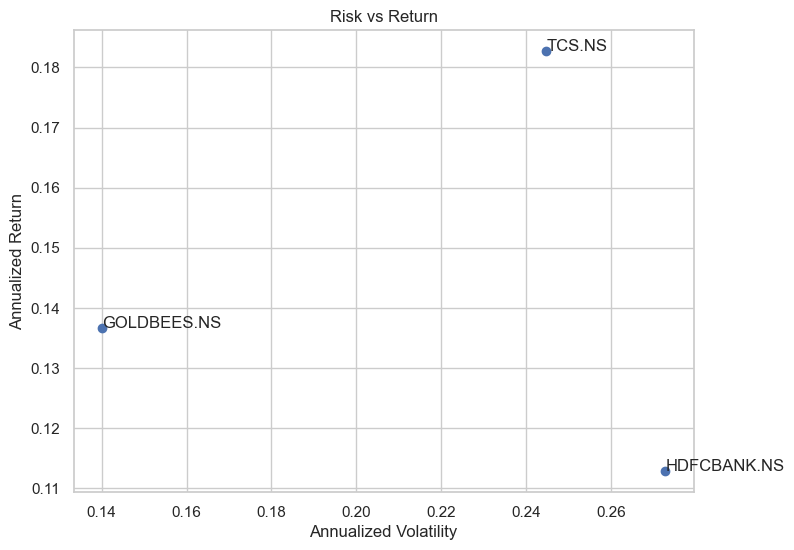

In [32]:
summary_df = pd.DataFrame({
    "Mean Return": simple_returns_df.mean() * 252,
    "Annualized Volatility": simple_returns_df.std() * (252 ** 0.5)
})

plt.figure(figsize=(8,6))
plt.scatter(
    summary_df["Annualized Volatility"],
    summary_df["Mean Return"]
)

for asset in summary_df.index:
    plt.annotate(
        asset,
        (
            summary_df.loc[asset, "Annualized Volatility"],
            summary_df.loc[asset, "Mean Return"]
        )
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Risk vs Return")
plt.grid(True)
plt.show()

In [33]:
risk_return_ratio = (
    summary_df["Mean Return"] /
    summary_df["Annualized Volatility"]
).sort_values(ascending=False)

display(risk_return_ratio)

Ticker
GOLDBEES.NS    0.975987
TCS.NS         0.746645
HDFCBANK.NS    0.413766
dtype: float64